In [2]:
#%pip install numpy pandas matplotlib statsmodels
#%pip install EMD-signal
#%pip install scikit-learn
#%pip install --upgrade plotly nbformat

# Illustrative example: STL

In [3]:
# 코드 필요

# Illustrative example: Toy data for each sector

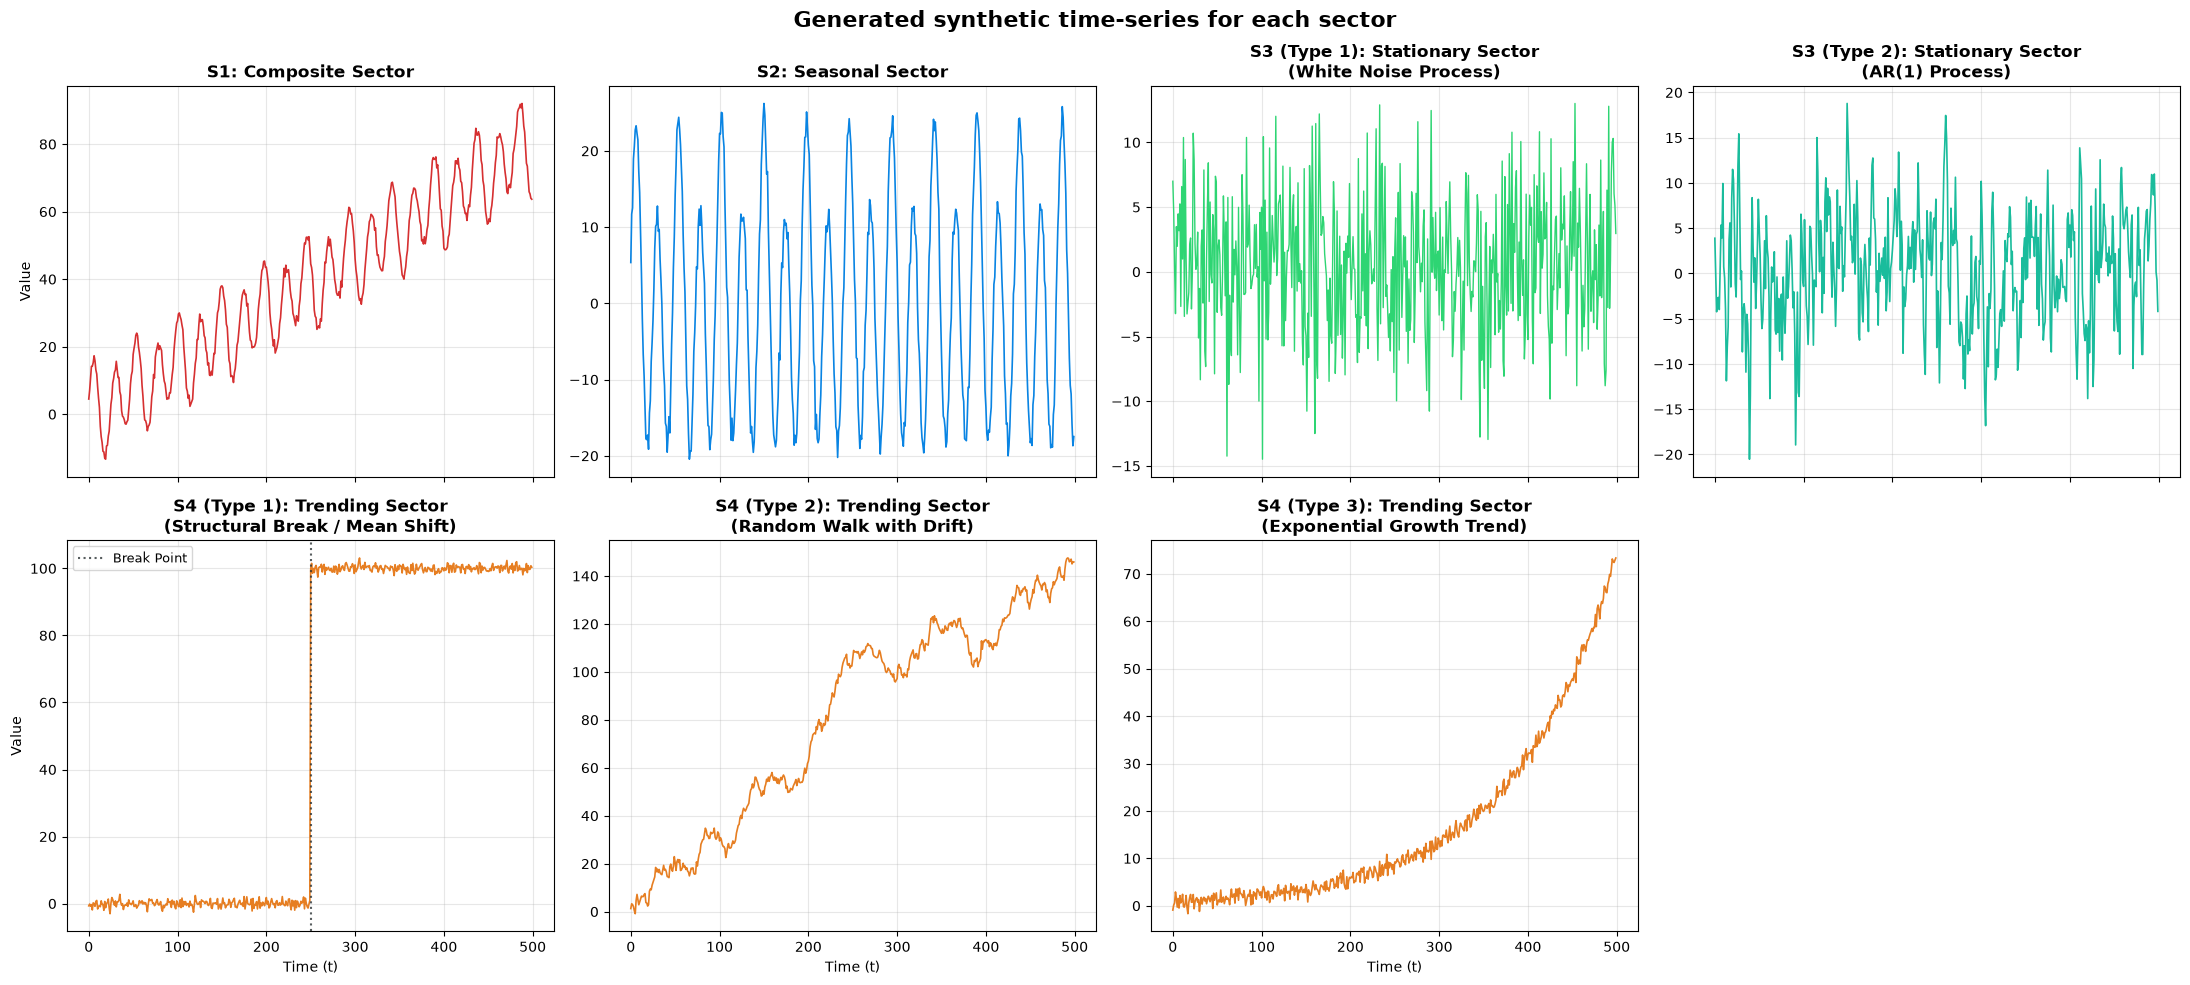

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 0. 글로벌 가상 데이터 공통 설정
# ----------------------------------------------------
length = 500
t = np.arange(length)
np.random.seed(42)  # 실험 재현성을 위한 시드 고정

# 서브플롯 Grid 구성 (2행 4열, 총 8개 패널로 확장)
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True)
axes = axes.flatten()

# ----------------------------------------------------
# 1. 🔴 R1 (Composite Regime): 강한 추세 + 강한 계절성
# ----------------------------------------------------
slope = 0.15
curve = 2e-5
amp1, amp2 = 12.0, 4.0
p1, p2 = 24, 48
noise_std_r1 = 1.0

y_R1 = (slope * t + curve * (t**2)) + \
       (amp1 * np.sin(2 * np.pi * t / p1)) + \
       (amp2 * np.cos(2 * np.pi * t / p2)) + \
       np.random.normal(0, noise_std_r1, length)

axes[0].plot(t, y_R1, color='#d63031', linewidth=1.2)
axes[0].set_title("S1: Composite Sector", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Value", fontsize=10)
axes[0].grid(True, alpha=0.3)

# ----------------------------------------------------
# 2. 🔵 R2 (Seasonal Regime): 약한 추세 + 강한 계절성
# ----------------------------------------------------
amp1_r2, amp2_r2 = 18.0, 6.0
p1_r2, p2_r2 = 24, 48
noise_std_r2 = 1.2

y_R2 = (amp1_r2 * np.sin(2 * np.pi * t / p1_r2)) + \
       (amp2_r2 * np.sin(2 * np.pi * t / p2_r2 + np.pi/4)) + \
       np.random.normal(0, noise_std_r2, length)

axes[1].plot(t, y_R2, color='#0984e3', linewidth=1.2)
axes[1].set_title("S2: Seasonal Sector", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ----------------------------------------------------
# 3. 🟢 R3 (Type 1): 순수 화이트 노이즈 (White Noise) ★추가된 부분
# ----------------------------------------------------
# AR(1)과 동일한 수준의 충격 스케일을 직관적으로 비교하기 위해 표준편차 설정
y_R3_wn = np.random.normal(0, 5.0, length)

axes[2].plot(t, y_R3_wn, color='#2ed573', linewidth=1.0)
axes[2].set_title("S3 (Type 1): Stationary Sector\n(White Noise Process)", fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# ----------------------------------------------------
# 4. 🟢 R3 (Type 2): 1차 자기회귀 프로세스 (AR(1) Process)
# ----------------------------------------------------
phi = 0.65
y_R3_ar = np.zeros(length)
innovations = np.random.normal(0, 5.0, length)
y_R3_ar[0] = innovations[0]
for idx in range(1, length):
    y_R3_ar[idx] = phi * y_R3_ar[idx-1] + innovations[idx]

axes[3].plot(t, y_R3_ar, color='#1abc9c', linewidth=1.2)
axes[3].set_title("S3 (Type 2): Stationary Sector\n(AR(1) Process)", fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)

# ----------------------------------------------------
# 5. 🟠 R4 - 변형 1: 구조적 단절 (Structural Break)
# ----------------------------------------------------
break_point = length // 2
y_R4_break = np.random.normal(0, 1.0, length)
y_R4_break[break_point:] += 100.0  # 평균 수직 도약 (Mean Shift)

axes[4].plot(t, y_R4_break, color='#e67e22', linewidth=1.2)
axes[4].axvline(x=break_point, color='#2d3436', linestyle=':', alpha=0.8, label='Break Point')
axes[4].set_title("S4 (Type 1): Trending Sector\n(Structural Break / Mean Shift)", fontsize=12, fontweight='bold')
axes[4].set_xlabel("Time (t)", fontsize=10)
axes[4].set_ylabel("Value", fontsize=10)
axes[4].legend(loc='upper left', fontsize=9)
axes[4].grid(True, alpha=0.3)

# ----------------------------------------------------
# 6. 🟠 R4 - 변형 2: 드리프트 랜덤 워크 (Random Walk with Drift)
# ----------------------------------------------------
drift = 0.25
y_R4_rw = np.cumsum(np.random.normal(drift, 1.8, length))  # 누적 충격 확률과정

axes[5].plot(t, y_R4_rw, color='#e67e22', linewidth=1.2)
axes[5].set_title("S4 (Type 2): Trending Sector\n(Random Walk with Drift)", fontsize=12, fontweight='bold')
axes[5].set_xlabel("Time (t)", fontsize=10)
axes[5].grid(True, alpha=0.3)

# ----------------------------------------------------
# 7. 🟠 R4 - 변형 3: 지수 성장 트렌드 (Exponential Growth Trend)
# ----------------------------------------------------
y_R4_exp = np.exp(np.linspace(0, 4.3, length)) + np.random.normal(0, 1.0, length)

axes[6].plot(t, y_R4_exp, color='#e67e22', linewidth=1.2)
axes[6].set_title("S4 (Type 3): Trending Sector\n(Exponential Growth Trend)", fontsize=12, fontweight='bold')
axes[6].set_xlabel("Time (t)", fontsize=10)
axes[6].grid(True, alpha=0.3)

# ----------------------------------------------------
# 8. 📊 마지막 빈 슬롯 레이아웃 여백 처리
# ----------------------------------------------------
axes[7].axis('off')  # 시각적 왜곡이 없도록 빈 패널 숨기기

# 전체 레이아웃 조율
plt.suptitle("Generated synthetic time-series for each sector", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Illustrative example: Motivating Observations for EMD

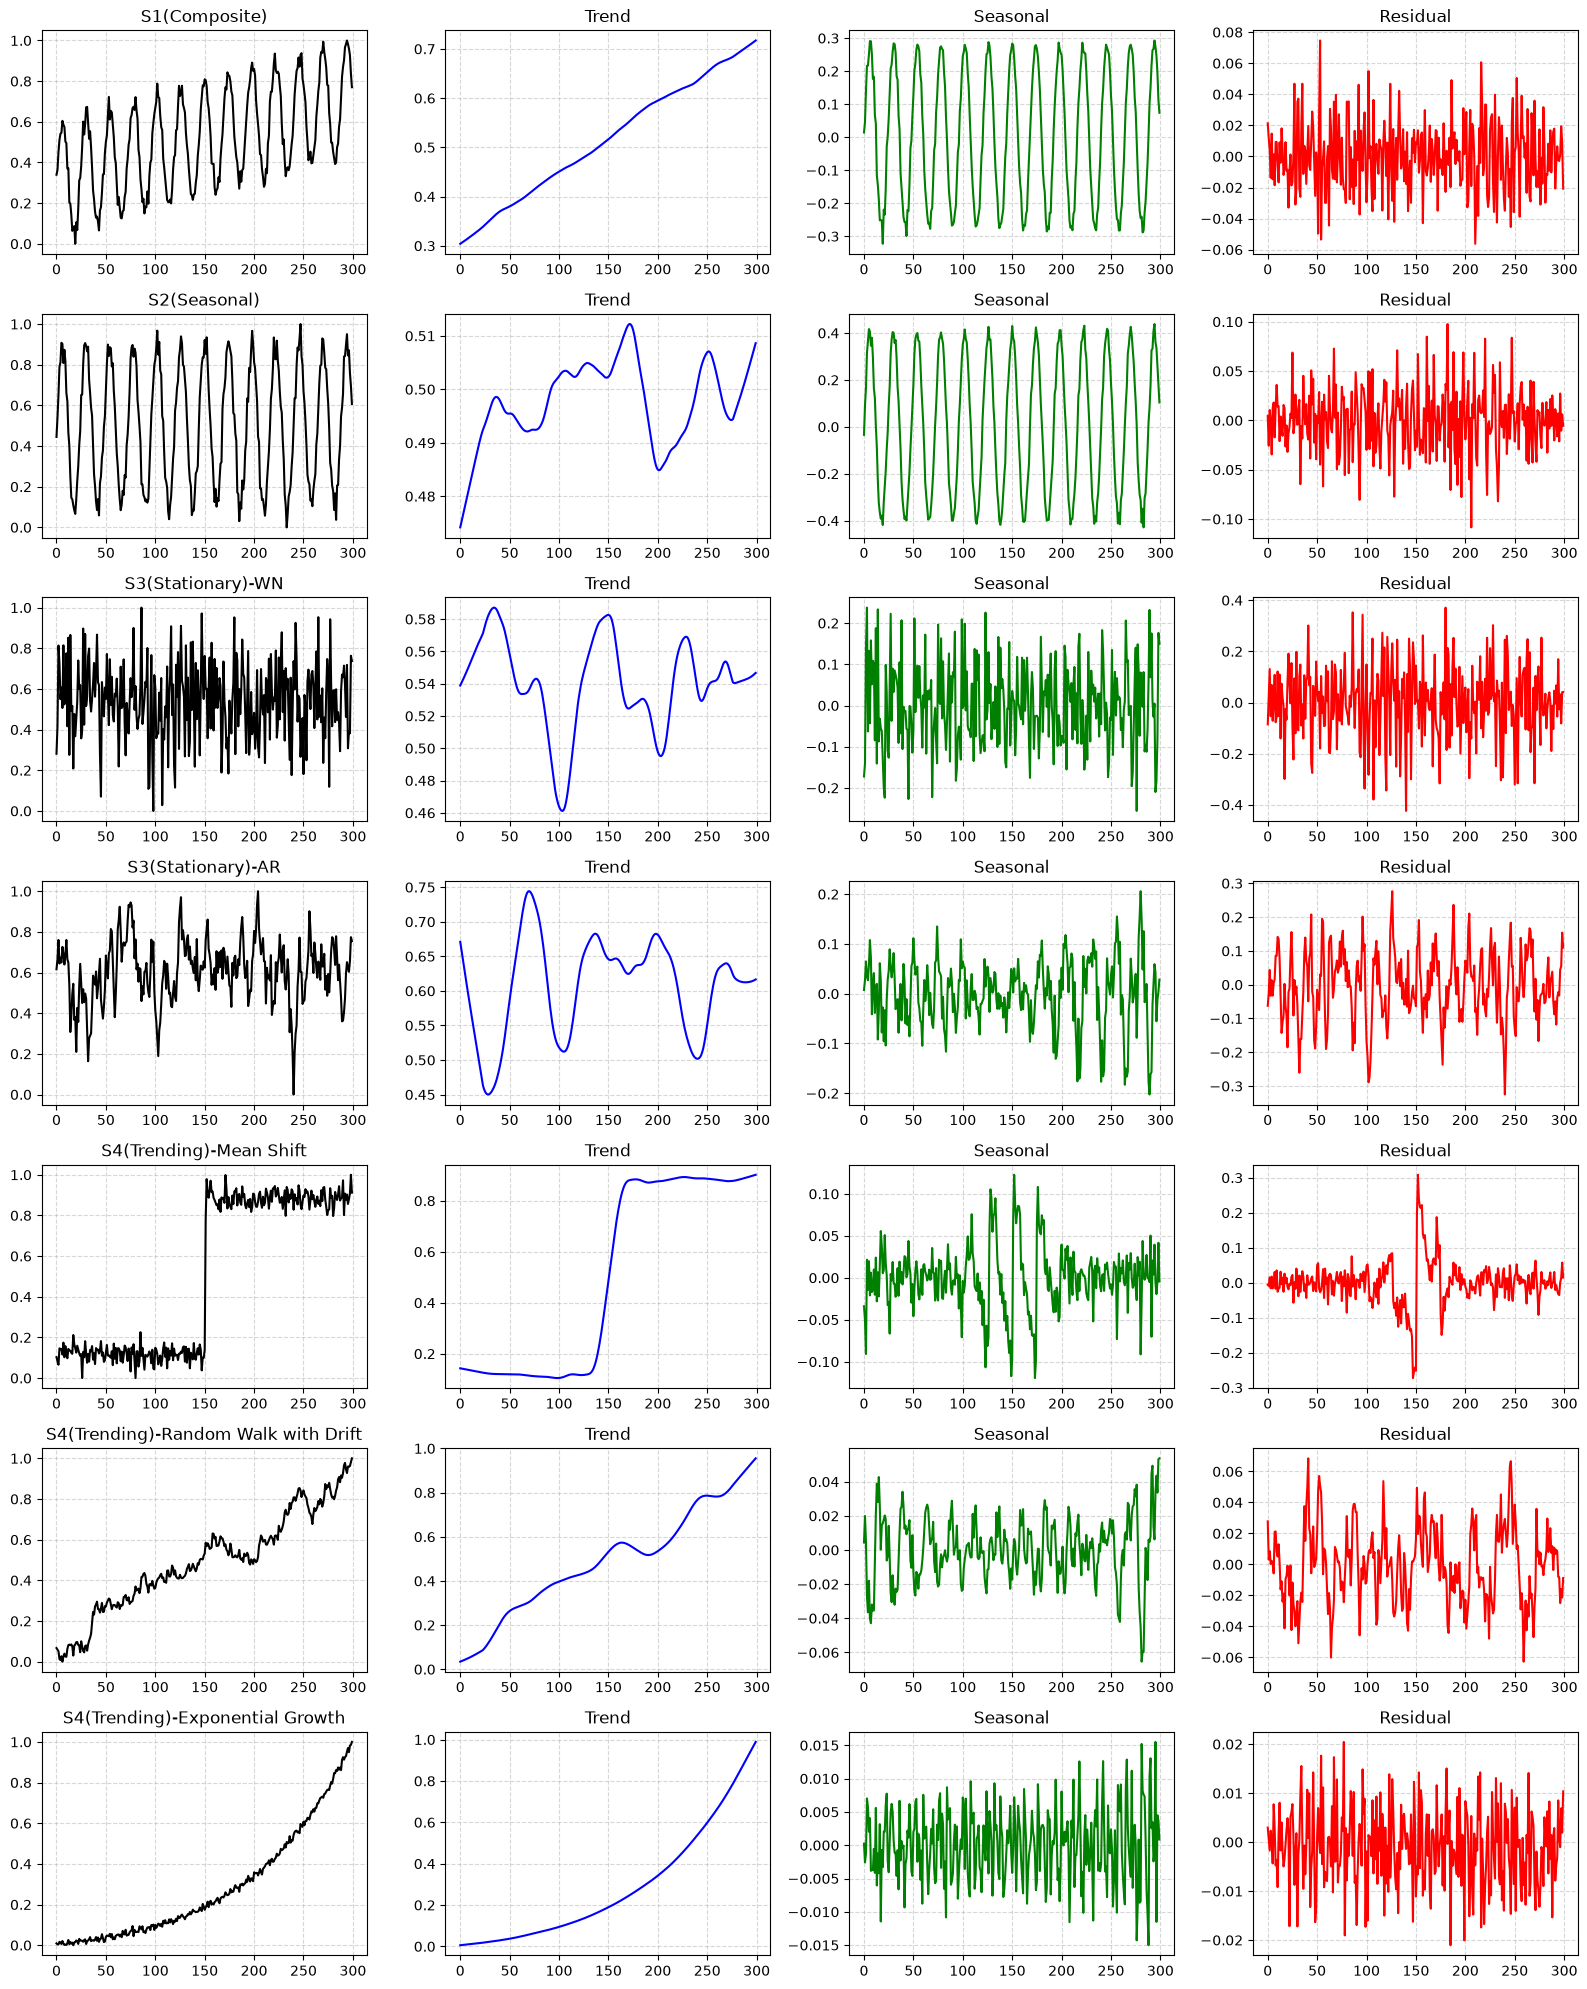

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import MinMaxScaler

# 1. 7가지 레짐 생성 (이전과 동일)
def generate_regimes(n=300):
    t = np.arange(n)
    r1 = 0.05 * t + 10 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 1, n)
    r2 = 10 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 1, n)
    r3_t1 = np.random.normal(0, 1, n)
    r3_t2 = np.zeros(n)
    for i in range(1, n): r3_t2[i] = 0.8 * r3_t2[i-1] + np.random.normal(0, 1)
    r4_t1 = np.where(t > n//2, 20, 0) + np.random.normal(0, 1, n)
    r4_t2 = np.cumsum(np.random.normal(0.1, 1, n))
    r4_t3 = 5 * np.exp(0.01 * t) + np.random.normal(0, 1, n)
    return {'S1(Composite)': r1, 'S2(Seasonal)': r2, 'S3(Stationary)-WN': r3_t1, 'S3(Stationary)-AR': r3_t2, 
            'S4(Trending)-Mean Shift': r4_t1, 'S4(Trending)-Random Walk with Drift': r4_t2, 'S4(Trending)-Exponential Growth': r4_t3}

data_dict = generate_regimes()
scaler = MinMaxScaler()

# 2. STL 분해 및 전체 성분 시각화 (Min-Max Scaling 포함)
fig, axes = plt.subplots(7, 4, figsize=(16, 20))

for i, (name, data) in enumerate(data_dict.items()):
    # Min-Max Scaling 적용 (2D 배열 형태 변경 필요)
    scaled_data = scaler.fit_transform(data.reshape(-1, 1)).flatten()
    
    stl = STL(scaled_data, period=24).fit()
    
    axes[i, 0].plot(scaled_data, color='black'); axes[i, 0].set_title(f"{name}")
    axes[i, 1].plot(stl.trend, color='blue'); axes[i, 1].set_title("Trend")
    axes[i, 2].plot(stl.seasonal, color='green'); axes[i, 2].set_title("Seasonal")
    axes[i, 3].plot(stl.resid, color='red'); axes[i, 3].set_title("Residual")
    
    for j in range(4): axes[i, j].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Illustrative example: EMD

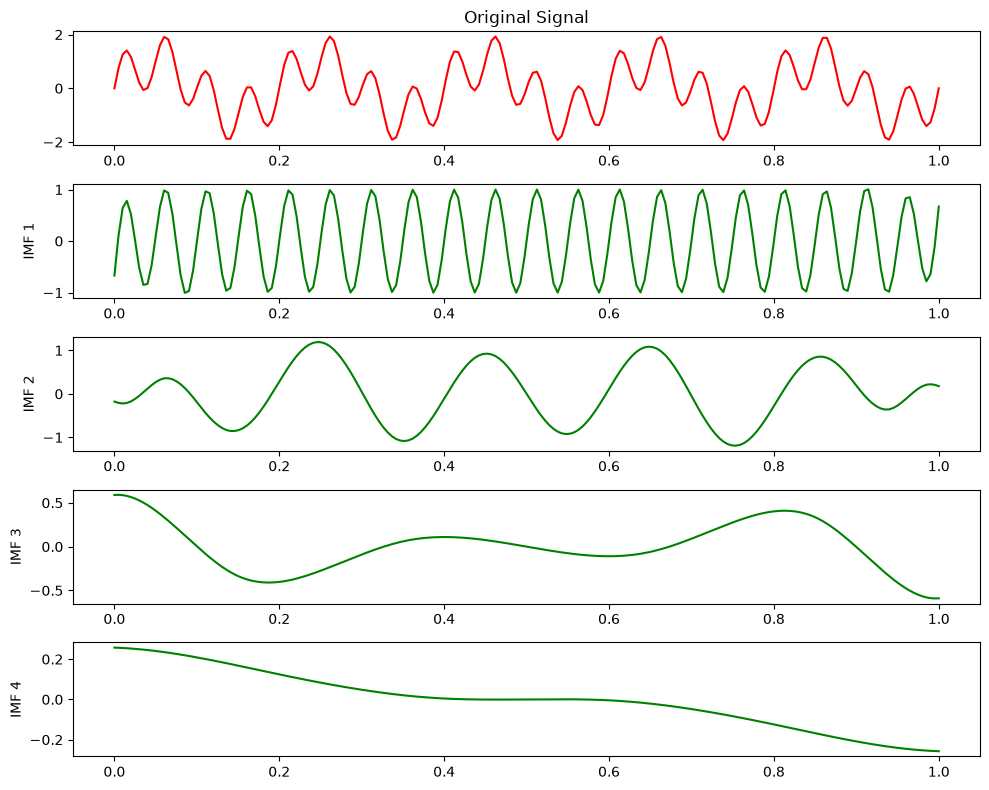

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

# 1. 샘플 데이터 생성
t = np.linspace(0, 1, 200)
s = np.sin(2 * np.pi * 5 * t) + np.sin(2 * np.pi * 20 * t)  # 5Hz와 20Hz 신호 혼합

# 2. EMD 객체 생성 및 분해
emd = EMD()
imfs = emd(s) # IMF들이 담긴 배열 반환

# 3. 결과 시각화
n_imfs = imfs.shape[0]
plt.figure(figsize=(10, 8))
plt.subplot(n_imfs + 1, 1, 1)
plt.plot(t, s, 'r')
plt.title("Original Signal")

for i in range(n_imfs):
    plt.subplot(n_imfs + 1, 1, i + 2)
    plt.plot(t, imfs[i], 'g')
    plt.ylabel(f"IMF {i+1}")

plt.tight_layout()
plt.show()

# Illustrative Example: STL-EMD로 Mean Shift 데이터 분해해서 T, S, I, R 성분 시각화

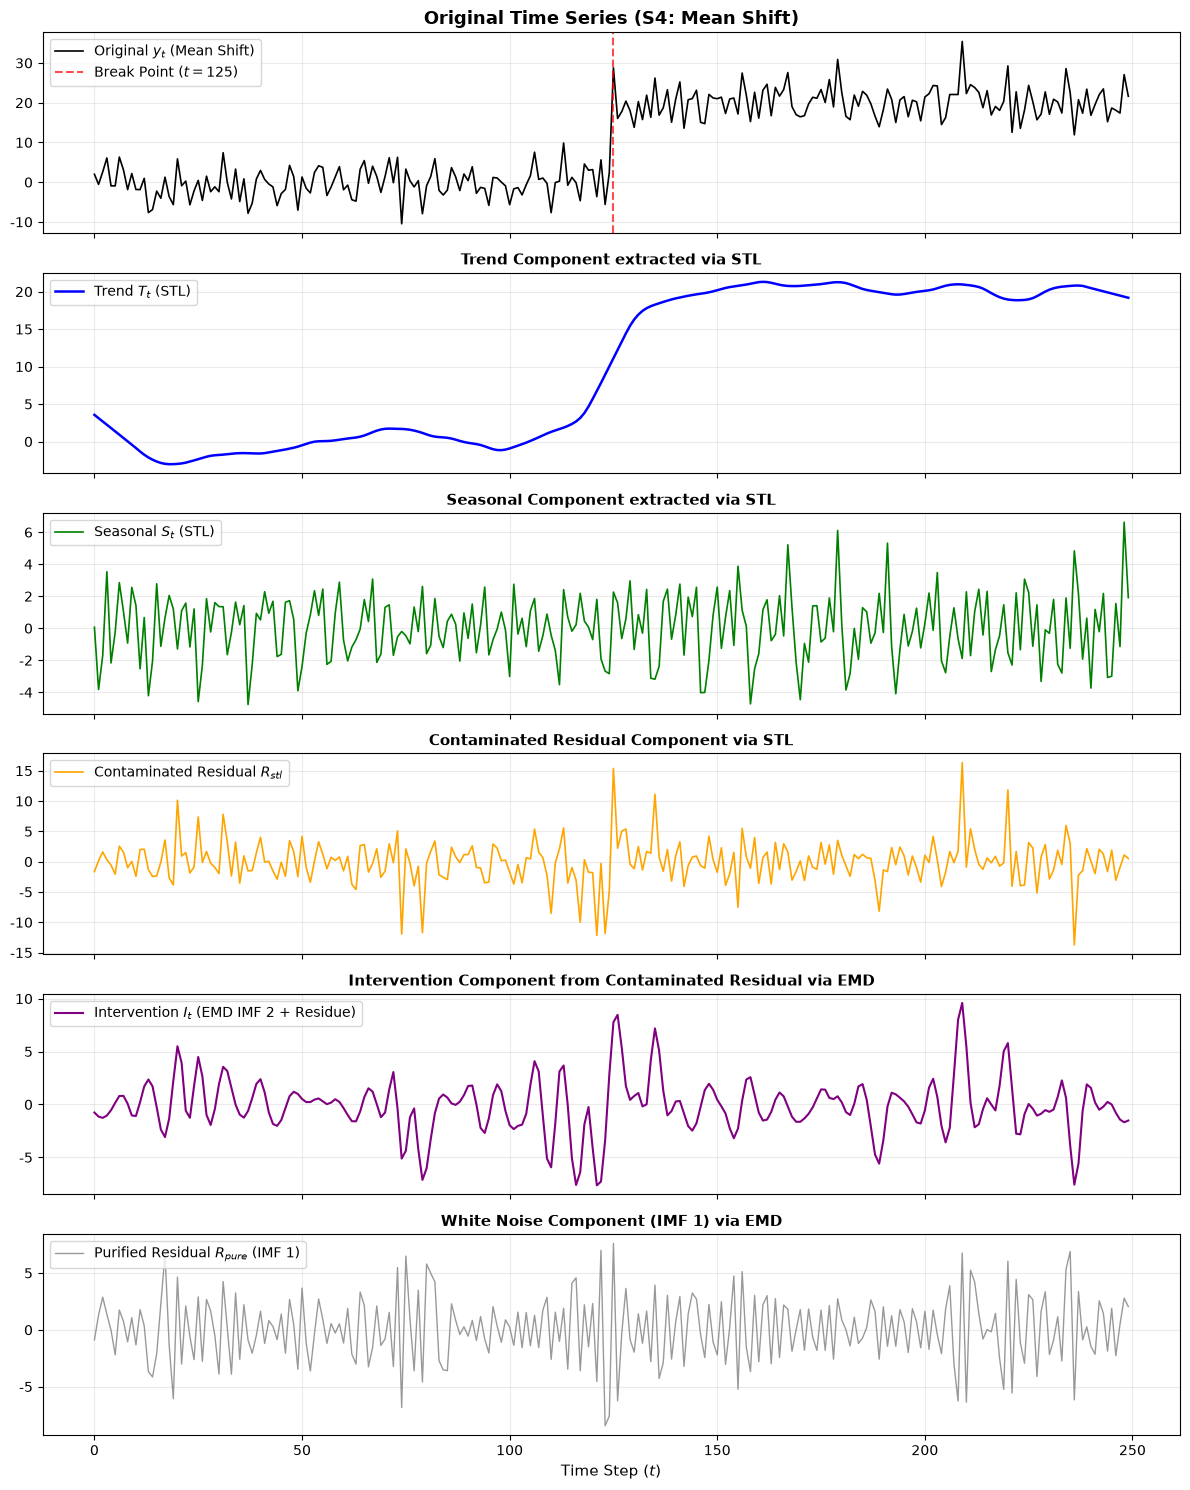

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from PyEMD import EMD

# 1. 연구용 샘플 데이터 생성 (R4 레짐 - Mean Shift 유형 고도화)
np.random.seed(42)
length = 250
noise_std = 4.0
bp_val = length // 2  # t=125 시점에 구조적 단절 발생

# 기저 생성 기전 (DGP): 순수 백색 잡음에 t=125부터 명확한 계단식 수직 점프(Mean Shift) 주입
pure_wn = np.random.normal(0, noise_std, length)
underlying_trend = np.zeros(length)
underlying_trend[bp_val:] = 20.0  # 강력한 개입 Shock 반영

q4_series = underlying_trend + pure_wn

# 2. 1단계: 전통적 STL 분해 수행
estimated_period = 12
stl = STL(q4_series, period=estimated_period, robust=True).fit()
T_stl = stl.trend
S_stl = stl.seasonal
R_stl = stl.resid  # 오염된 잔차 (의사 계절성 및 쇼크 변동성 누출)

# 3. 2단계: EMD 기반 잔차 공간 재분해 (연구자님의 IMF_1 격리 로직 적용)
emd = EMD()
imfs = emd.emd(R_stl)

# [수정 핵심 수리 로직]: 최고주파 성분인 IMF 1을 순수 백색 잡음으로 정의
if len(imfs) > 1:
    R_pure = imfs[0]                   # IMF 1 -> 순수 백색 잡음 (White Noise) 격리
    I_emd = np.sum(imfs[1:], axis=0)   # IMF 2 ~ 최종 Residue의 합 -> 결정론적 개입 충격 성분 ($I_t$)
else:
    R_pure = R_stl
    I_emd = np.zeros(length)

# 4. 학술 장표용 6단 구성 시각화 (Original -> T -> S -> R_stl -> I -> Pure R)
fig, axes = plt.subplots(6, 1, figsize=(12, 15), sharex=True)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# [Plot 1] 원본 시계열 데이터
axes[0].plot(q4_series, color='black', linewidth=1.2, label='Original $y_t$ (Mean Shift)')
axes[0].axvline(x=bp_val, color='red', linestyle='--', alpha=0.7, label='Break Point ($t=125$)')
axes[0].set_title('Original Time Series (S4: Mean Shift)', fontsize=13, weight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.25)

# [Plot 2] STL 추세 성분 (S자 형태로 왜곡된 트렌드)
axes[1].plot(T_stl, color='blue', linewidth=1.8, label='Trend $T_t$ (STL)')
axes[1].set_title('Trend Component extracted via STL', fontsize=11, weight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.25)

# [Plot 3] STL 가짜 계절성 (단절점 부근에서 억지로 짜내진 주기성 누출)
axes[2].plot(S_stl, color='green', linewidth=1.2, label='Seasonal $S_t$ (STL)')
axes[2].set_title('Seasonal Component extracted via STL', fontsize=11, weight='bold')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.25)

# [Plot 4] 1단계 결과물: 오염되고 왜곡된 STL 잔차
axes[3].plot(R_stl, color='orange', linewidth=1.2, label='Contaminated Residual $R_{stl}$')
axes[3].set_title('Contaminated Residual Component via STL', fontsize=11, weight='bold')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.25)

# [Plot 5] 2단계 혁신: 잔차 공간에서 순수 구조적 충격만 복원한 개입 성분
axes[4].plot(I_emd, color='purple', linewidth=1.5, label='Intervention $I_t$ (EMD IMF 2 + Residue)')
#axes[4].axvline(x=bp_val, color='red', linestyle='--', alpha=0.5)
axes[4].set_title('Intervention Component from Contaminated Residual via EMD', fontsize=11, weight='bold')
axes[4].legend(loc='upper left')
axes[4].grid(True, alpha=0.25)

# [Plot 6] 2단계 혁신: 정제된 순수 백색 잡음 (IMF 1)
axes[5].plot(R_pure, color='gray', linewidth=1.0, alpha=0.8, label='Purified Residual $R_{pure}$ (IMF 1)')
axes[5].set_title('White Noise Component (IMF 1) via EMD', fontsize=11, weight='bold')
axes[5].legend(loc='upper left')
axes[5].grid(True, alpha=0.25)
axes[5].set_xlabel('Time Step ($t$)', fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
#import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from PyEMD import EMD  # pip install PyEMD
from sklearn.preprocessing import MinMaxScaler

# STL-EMD based DATC Functions

In [ ]:
def estimate_period_fft(series, default_period=24):
    """
    FFT를 활용하여 시계열 데이터에서 가장 지배적인 주기를 동적으로 추정합니다.
    """
    n = len(series)
    t = np.arange(n)
    
    # 1. FFT 전처리: 선형 추세 및 평균(DC 성분) 제거
    p = np.polyfit(t, series, 1)
    detrended = series - np.polyval(p, t)
    detrended = detrended - np.mean(detrended)
    
    # 2. FFT 수행 및 진폭 계산
    fft_vals = np.fft.rfft(detrended)
    frequencies = np.fft.rfftfreq(n)
    magnitudes = np.abs(fft_vals)
    
    # 3. 0Hz(상수항)를 제외하고 진폭이 가장 큰 인덱스 탐색
    if len(magnitudes) > 1:
        dominant_idx = np.argmax(magnitudes[1:]) + 1 
        dominant_freq = frequencies[dominant_idx]
        
        if dominant_freq > 0:
            period = int(np.round(1.0 / dominant_freq))
            if 2 <= period <= n // 2:
                return period
                
    return default_period

def calculate_time_series_strength(series):
    """
    1. 고전적 STL 분해: y = T + S + R_stl -> F_T_STL, F_S_STL 산출
    2. STL-EMD 하이브리드 분해: y = T + S + I + R_pure -> F_T_STL_EMD, F_S_STL_EMD, F_I_STL_EMD 산출
    """
    estimated_p = estimate_period_fft(series)
    
    if len(series) < 2 * estimated_p:
        estimated_p = max(2, len(series) // 2 - 1)
        
    try:
        # [1단계] 고전적 STL 분해 수행 (y = T + S + R_stl)
        res = STL(series, period=estimated_p, robust=True).fit()
        T, S, R_stl = res.trend, res.seasonal, res.resid
        
        var_R_stl = np.var(R_stl)
        var_TR_stl = np.var(T + R_stl)
        var_SR_stl = np.var(S + R_stl)
        
        # STL 기반 피처 연산
        F_T_STL = max(0.0, 1.0 - (var_R_stl / var_TR_stl if var_TR_stl > 0 else 1.0))
        F_S_STL = max(0.0, 1.0 - (var_R_stl / var_SR_stl if var_SR_stl > 0 else 1.0))
        F_R_STL = max(0.0, 1.0 - (1 / var_R_stl if var_R_stl > 0 else 1.0))

        # print(f'=====================================================================================================')
        # print(f'var_R_stl: {var_R_stl:.4f}, 1/var_R_stl: {1/var_R_stl:.4f}, F_R_STL: {F_R_STL:.4f}')
        
        # [2단계] EMD 분해 기동 (R_stl을 I + R_pure로 분리)
        emd = EMD()
        imfs = emd.emd(R_stl)
        
        if len(imfs) > 2:
            I = np.sum(imfs[1:], axis=0) 
        elif len(imfs) == 2:
            I = imfs[1]
        else:
            I = np.zeros_like(R_stl)
            
        # 순수 가우시안 확률 노이즈 정제 (y = T + S + I + R_pure)
        R_pure = R_stl - I
        
        # 최종 정제된 R_pure 기반의 강도 재연산
        var_R_pure = np.var(R_pure)
        var_TR_pure = np.var(T + R_pure) 
        var_SR_pure = np.var(S + R_pure)
        var_IR_pure = np.var(I + R_pure) 
        
        # STL-EMD 기반 피처 연산
        F_T_STL_EMD = max(0.0, 1.0 - (var_R_pure / var_TR_pure if var_TR_pure > 0 else 1.0))
        F_S_STL_EMD = max(0.0, 1.0 - (var_R_pure / var_SR_pure if var_SR_pure > 0 else 1.0))
        F_I_STL_EMD = max(0.0, 1.0 - (var_R_pure / var_IR_pure if var_IR_pure > 0 else 1.0))
            
    except Exception:
        # 수리적 예외 발생 시 0.0 반환
        F_T_STL, F_S_STL, F_R_STL = 0.0, 0.0, 0.0
        F_T_STL_EMD, F_S_STL_EMD, F_I_STL_EMD = 0.0, 0.0, 0.0
        
    return F_T_STL, F_S_STL, F_R_STL, F_T_STL_EMD, F_S_STL_EMD, F_I_STL_EMD, estimated_p


def generate_synthetic_dataset(num_samples_per_regime=50, len_series=500):
    """
    모든 시계열 샘플에 대해 STL 피처와 STL-EMD 피처를 모두 산출하여 기록하는 데이터셋 생성기
    """
    print(f"🔹 Generating synthetic dataset (Samples/Regime: {num_samples_per_regime}, Length: {len_series})")

    data_records = []
    t = np.arange(len_series)
    
    for i in range(num_samples_per_regime):
        print(f"Generating sample {i+1}/{num_samples_per_regime} for each regime...")
        rand_p1 = np.random.choice([12, 24, 36, 48])
        rand_p2 = rand_p1 * 2
        
        # --- R1: Composite Regime (High Trend + High Seasonality) ---
        slope = np.random.uniform(0.1, 0.4) * np.random.choice([1, -1])
        curve = np.random.uniform(1e-5, 5e-5) * np.random.choice([1, -1])
        amp1, amp2 = np.random.uniform(8, 25), np.random.uniform(2, 8)
        noise_std = np.random.uniform(0.5, 1.5)
        
        q1_series = (slope * t + curve * (t**2)) + (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, len_series)
        q1_scaled = (q1_series - np.min(q1_series)) / (np.max(q1_series) - np.min(q1_series) + 1e-9)
        ft_stl, fs_stl, fr_stl, ft_stl_emd, fs_stl_emd, fi_stl_emd, p_est = calculate_time_series_strength(q1_scaled)
        
        data_records.append({
            'True_Sector': 'S1', 'Pattern': 'Composite', 
            'F_T_STL': ft_stl, 'F_S_STL': fs_stl, 'F_R_STL': fr_stl,
            'F_T_STL_EMD': ft_stl_emd, 'F_S_STL_EMD': fs_stl_emd, 'F_I_STL_EMD': fi_stl_emd, 
            'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': len_series, 'slope': slope, 'curve': curve,
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std, 'phi': None, 'break_point': None, 'drift': None
        })
        
        # --- S2: Pure Seasonal (Low Trend + High Seasonality) ---
        amp1, amp2 = np.random.uniform(10, 30), np.random.uniform(4, 12)
        noise_std = np.random.uniform(0.5, 2.0)
        
        q2_series = (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, len_series)
        q2_scaled = (q2_series - np.min(q2_series)) / (np.max(q2_series) - np.min(q2_series) + 1e-9)
        ft_stl, fs_stl, fr_stl, ft_stl_emd, fs_stl_emd, fi_stl_emd, p_est = calculate_time_series_strength(q2_scaled)
        
        data_records.append({
            'True_Sector': 'S2', 'Pattern': 'Seasonal', 
            'F_T_STL': ft_stl, 'F_S_STL': fs_stl, 'F_R_STL': fr_stl,
            'F_T_STL_EMD': ft_stl_emd, 'F_S_STL_EMD': fs_stl_emd, 'F_I_STL_EMD': fi_stl_emd, 
            'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': len_series, 'slope': 0.0, 'curve': 0.0,
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std, 'phi': None, 'break_point': None, 'drift': None
        })

        # --- S3: Stationary / Noise (Low Trend + Low Seasonality) ---
        noise_type = np.random.choice(['WN', 'AR'])
        phi_val = None
        
        if noise_type == 'WN':
            noise_std_wn = np.random.uniform(5, 15)
            q3_series = np.random.normal(0, noise_std_wn, len_series)
            current_noise_std = noise_std_wn
        else:
            phi_val = np.random.uniform(0.4, 0.7)
            q3_series = np.zeros(len_series)
            innovations_std = 5.0
            innovations = np.random.normal(0, innovations_std, len_series)
            q3_series[0] = innovations[0]
            for idx in range(1, len_series):
                q3_series[idx] = phi_val * q3_series[idx-1] + innovations[idx]
            current_noise_std = innovations_std

        q3_scaled = (q3_series - np.min(q3_series)) / (np.max(q3_series) - np.min(q3_series) + 1e-9)
        ft_stl, fs_stl, fr_stl, ft_stl_emd, fs_stl_emd, fi_stl_emd, p_est = calculate_time_series_strength(q3_scaled)
        
        data_records.append({
            'True_Sector': 'S3', 'Pattern': f'Stationary_{noise_type}', 
            'F_T_STL': ft_stl, 'F_S_STL': fs_stl, 'F_R_STL': fr_stl,
            'F_T_STL_EMD': ft_stl_emd, 'F_S_STL_EMD': fs_stl_emd, 'F_I_STL_EMD': fi_stl_emd, 
            'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': len_series, 'slope': 0.0, 'curve': 0.0, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': current_noise_std, 'phi': phi_val, 'break_point': None, 'drift': None
        })

        # --- S4: Pure Trending with Mean Shift (High Trend + Low Seasonality) ---
        trend_type = np.random.choice(['MeanShift', 'RandomWalkDrift', 'ExponentialGrowth'])
        noise_std = np.random.uniform(0.5, 1.5)
        bp_val = None
        drift_val = None
        
        if trend_type == 'MeanShift':
            bp_val = len_series // 2
            q4_series = np.random.normal(0, noise_std, len_series)
            q4_series[bp_val:] += np.random.uniform(50, 150)
        elif trend_type == 'RandomWalkDrift':
            drift_val = np.random.uniform(0.1, 0.5) * np.random.choice([1, -1])
            q4_series = np.cumsum(np.random.normal(drift_val, 2, len_series))
        else:
            q4_series = np.exp(np.linspace(0, np.random.uniform(3, 5), len_series)) + np.random.normal(0, noise_std, len_series)

        q4_scaled = (q4_series - np.min(q4_series)) / (np.max(q4_series) - np.min(q4_series) + 1e-9)
        ft_stl, fs_stl, fr_stl, ft_stl_emd, fs_stl_emd, fi_stl_emd, p_est = calculate_time_series_strength(q4_scaled)
        
        data_records.append({
            'True_Sector': 'S4', 'Pattern': f'Trending_{trend_type}', 
            'F_T_STL': ft_stl, 'F_S_STL': fs_stl, 'F_R_STL': fr_stl,
            'F_T_STL_EMD': ft_stl_emd, 'F_S_STL_EMD': fs_stl_emd, 'F_I_STL_EMD': fi_stl_emd, 
            'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': len_series, 'slope': None, 'curve': None, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': noise_std, 'phi': None, 'break_point': bp_val, 'drift': drift_val
        })
        
    return pd.DataFrame(data_records)

In [30]:
#df_exp_results = generate_synthetic_dataset(num_samples_per_regime=1000, len_series=500, dec_method='stl')
df_exp_results = generate_synthetic_dataset(num_samples_per_regime=500, len_series=300)
df_exp_results.to_csv('../../results/temp/0902_Per500_Len300_synthetic_dataset.csv', index=False)

🔹 Generating synthetic dataset (Samples/Regime: 500, Length: 300)
Generating sample 1/500 for each regime...
var_R_stl: 0.0012, 1/var_R_stl: 801.1908, F_R_STL: 0.0000
var_R_stl: 0.0045, 1/var_R_stl: 222.8013, F_R_STL: 0.0000
var_R_stl: 0.0178, 1/var_R_stl: 56.2057, F_R_STL: 0.0000
var_R_stl: 0.0014, 1/var_R_stl: 732.3975, F_R_STL: 0.0000
Generating sample 2/500 for each regime...
var_R_stl: 0.0001, 1/var_R_stl: 13850.5698, F_R_STL: 0.0000
var_R_stl: 0.0047, 1/var_R_stl: 213.1608, F_R_STL: 0.0000
var_R_stl: 0.0087, 1/var_R_stl: 115.1374, F_R_STL: 0.0000
var_R_stl: 0.0015, 1/var_R_stl: 681.8552, F_R_STL: 0.0000
Generating sample 3/500 for each regime...
var_R_stl: 0.0008, 1/var_R_stl: 1178.9788, F_R_STL: 0.0000
var_R_stl: 0.0040, 1/var_R_stl: 251.9196, F_R_STL: 0.0000
var_R_stl: 0.0156, 1/var_R_stl: 63.9309, F_R_STL: 0.0000
var_R_stl: 0.0001, 1/var_R_stl: 8677.7797, F_R_STL: 0.0000
Generating sample 4/500 for each regime...
var_R_stl: 0.0006, 1/var_R_stl: 1679.7214, F_R_STL: 0.0000
var_R

KeyboardInterrupt: 

In [24]:
df_exp_results = pd.read_csv('../../results/temp/0715_Per3000_Len500_synthetic_dataset.csv')

df_exp_results = df_exp_results.fillna(0)
#df_exp_results[df_exp_results['Pattern'].str.contains('Trending')].head(10)
df_exp_results.head(100)

,True_Sector,Pattern,F_T_STL,F_S_STL,F_R_STL,F_T_STL_EMD,F_S_STL_EMD,F_I_STL_EMD,True_P,Est_P,...,rand_p2,length,slope,curve,amp1,amp2,noise_std,phi,break_point,drift
0,S1,Composite,0.998194,0.967415,0.0,0.999763,0.995203,0.868768,48.0,50,...,96.0,500,0.380384,0.000048,19.170893,4.614037,1.230039,0.000000,0.0,0.000000
1,S2,Seasonal,0.610391,0.952528,0.0,0.890066,0.996252,0.929416,48.0,50,...,96.0,500,0.000000,0.000000,22.661961,7.954191,1.359942,0.000000,0.0,0.000000
2,S3,Stationary_AR,0.038663,0.241651,0.0,0.076088,0.418347,0.501500,0.0,50,...,0.0,500,0.000000,0.000000,0.000000,0.000000,5.000000,0.425697,0.0,0.000000
3,S4,Trending_ExponentialGrowth,0.969157,0.232895,0.0,0.981485,0.392301,0.415429,0.0,24,...,0.0,500,0.000000,0.000000,0.000000,0.000000,1.372754,0.000000,0.0,0.000000
4,S1,Composite,0.962301,0.950718,0.0,0.998386,0.998009,0.961582,36.0,36,...,72.0,500,0.117311,-0.000033,18.574673,7.954654,0.886323,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,S4,Trending_RandomWalkDrift,0.994820,0.235325,0.0,0.999180,0.659891,0.843853,0.0,24,...,0.0,500,0.000000,0.000000,0.000000,0.000000,1.052548,0.000000,0.0,-0.176997
96,S1,Composite,0.998791,0.994993,0.0,0.999897,0.999571,0.914884,36.0,36,...,72.0,500,0.209470,0.000019,21.856798,2.696357,0.518731,0.000000,0.0,0.000000
97,S2,Seasonal,0.688393,0.957302,0.0,0.896725,0.996419,0.919516,36.0,36,...,72.0,500,0.000000,0.000000,16.334490,6.233520,1.046596,0.000000,0.0,0.000000
98,S3,Stationary_AR,0.160595,0.201038,0.0,0.430237,0.479151,0.679596,0.0,16,...,0.0,500,0.000000,0.000000,0.000000,0.000000,5.000000,0.611805,0.0,0.000000


# STL experiment result: F_T, F_S

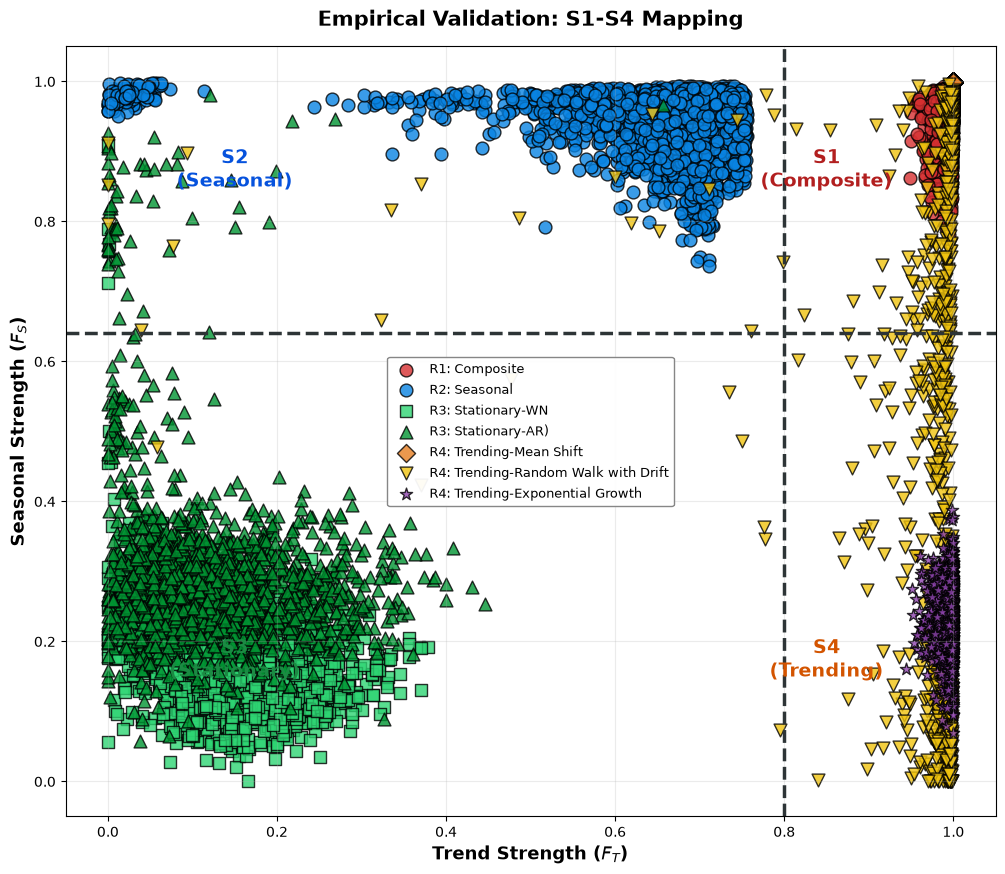


     [오라클 검증 통계 리포트 (임계치: 0.64)]
▶ S1: Composite Regime
  - 생성 패턴 예시: <ArrowStringArray>['Composite']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.994 | Mean F_S = 0.957
  - FFT 주기 추정 정확도: 75.6%
  - 사분면 매핑 성공률 : [ 3000 / 3000 ] (100.0%)
------------------------------------------------------------
▶ S2: Seasonal Regime
  - 생성 패턴 예시: <ArrowStringArray>['Seasonal']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.643 | Mean F_S = 0.943
  - FFT 주기 추정 정확도: 74.2%
  - 사분면 매핑 성공률 : [ 3000 / 3000 ] (100.0%)
------------------------------------------------------------
▶ S3: Stationary Regime
  - 생성 패턴 예시: <ArrowStringArray>['Stationary_AR', 'Stationary_WN']Length: 2, dtype: str
  - 평균 지표값  : Mean F_T = 0.134 | Mean F_S = 0.240
  - 사분면 매핑 성공률 : [ 2936 / 3000 ] (97.9%)
------------------------------------------------------------
▶ S4: Trending Regime
  - 생성 패턴 예시: <ArrowStringArray>['Trending_ExponentialGrowth', 'Trending_RandomWalkDrift', 'Trending_MeanShift']Length: 3, dtype: str
  - 평균 지표값  

In [ ]:
# ==========================================
# 2. 결과 시각화 (R1~R4 범례 순서 고정 및 세부 패턴 플롯팅)
# ==========================================
F_T_thr = 0.80
F_S_thr = 0.64

plt.figure(figsize=(12, 10))

# 1. 학술적 일관성을 위해 패턴별 고유 시각 세팅 테이블 정의
pattern_configs = {
    'Composite':                    {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite'},
    'Seasonal':                     {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal'},
    'Stationary_WN':                {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary-WN'},
    'Stationary_AR':                {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary-AR)'},
    'Trending_MeanShift':           {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending-Mean Shift'},
    'Trending_RandomWalkDrift':     {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending-Random Walk with Drift'},
    'Trending_ExponentialGrowth':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}
}

# 2. 범례 순서를 R1 -> R2 -> R3 -> R4 순으로 강제 정렬하기 위한 마스터 맵 순서 선언
legend_order = [
    'Composite',
    'Seasonal',
    'Stationary_WN',
    'Stationary_AR',
    'Trending_MeanShift',
    'Trending_RandomWalkDrift',
    'Trending_ExponentialGrowth'
]

# 3. 데이터프레임 내에 존재하는 패턴만 필터링하여 순서대로 플롯팅 (범례 순서 꼬임 원천 차단)
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    
    plt.scatter(group['F_T_STL'], group['F_S_STL'], 
                label=config['label'], color=config['color'], marker=config['marker'],
                alpha=0.8, edgecolors='k', s=85)

# 오라클 결정 가이드라인 경계선 (tau = 0.64)
plt.axvline(x=F_T_thr, color='#2d3436', linestyle='--', linewidth=2.5)
plt.axhline(y=F_S_thr, color='#2d3436', linestyle='--', linewidth=2.5)

# 사분면 텍스트 표기
plt.text(0.85, 0.85, 'S1\n(Composite)', fontsize=14, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.15, 0.85, 'S2\n(Seasonal)', fontsize=14, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.15, 0.15, 'S3\n(Stationary)', fontsize=14, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.85, 0.15, 'S4\n(Trending)', fontsize=14, fontweight='bold', ha='center', color='#d35400')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation: S1-S4 Mapping', fontsize=15, fontweight='bold', pad=15)

# 범례 정중앙 위치 설정 (가독성을 위한 반투명 흰색 배경막 장착)
plt.legend(loc='center', fontsize=9.5, framealpha=0.95, facecolor='white', edgecolor='gray')
plt.grid(True, alpha=0.25)
plt.show()

# ==========================================
# 3. 오라클 분류 정확도 결산 리포트 출력
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (임계치: 0.64)]")
print("="*60)

regime_names = {'S1': 'Composite Regime', 'S2': 'Seasonal Regime', 'S3': 'Stationary Regime', 'S4': 'Trending Regime'}

total_success = 0
# 데이터셋 내의 고유 레짐 라벨을 기준으로 루프 실행
for r_label in ['S1', 'S2', 'S3', 'S4']:
    sub_df = df_exp_results[df_exp_results['True_Sector'] == r_label]
    
    # 사분면 조건문 (S1~S4 로직 반영)
    if r_label == 'S1':
        success_condition = (sub_df['F_T_STL'] >= F_T_thr) & (sub_df['F_S_STL'] >= F_S_thr)
    elif r_label == 'S2':
        success_condition = (sub_df['F_T_STL'] < F_T_thr) & (sub_df['F_S_STL'] >= F_S_thr)
    elif r_label == 'S3':
        success_condition = (sub_df['F_T_STL'] < F_T_thr) & (sub_df['F_S_STL'] < F_S_thr)
    elif r_label == 'S4':
        success_condition = (sub_df['F_T_STL'] >= F_T_thr) & (sub_df['F_S_STL'] < F_S_thr)
        
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    unique_patterns = list(sub_df['Pattern'].unique())
    print(f"▶ {r_label}: {regime_names[r_label]}")
    print(f"  - 생성 패턴 예시: <ArrowStringArray>{unique_patterns}Length: {len(unique_patterns)}, dtype: str")
    print(f"  - 평균 지표값  : Mean F_T = {sub_df['F_T_STL'].mean():.3f} | Mean F_S = {sub_df['F_S_STL'].mean():.3f}")
    
    # 주기 매칭 검증 (S1, S2에 대해서만 추출 성과 체크)
    if r_label in ['S1', 'S2']:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("="*60)

# STL-EMD experiment result: F_T, F_S, F_I

In [28]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd

# 1. 임곗값(Threshold) 상수 정의
F_T_thr = 0.8
F_S_thr = 0.64
F_I_thr = 0.45

# 축의 전체 렌더링 범위 정의
axis_min, axis_max = -0.05, 1.05

# 2. 평면(Plane) 격자 데이터 생성을 위한 좌표 배열 준비
grid_resolution = 10
u = np.linspace(axis_min, axis_max, grid_resolution)
v = np.linspace(axis_min, axis_max, grid_resolution)
U, V = np.meshgrid(u, v)

# 3. 고유 시각 세팅 테이블 선언 (Solid 마커 규격)
pattern_configs = {
    'Composite':                  {'color': '#d63031', 'symbol': 'circle', 'label': 'S1: Composite'},

    'Seasonal':                   {'color': '#0984e3', 'symbol': 'circle', 'label': 'S2: Seasonal'},

    'Stationary_WN':              {'color': '#009432', 'symbol': 'circle', 'label': 'S3: Stationary-WN'},
    'Stationary_AR':              {'color': '#009432', 'symbol': 'x', 'label': 'S3: Stationary-AR'},

    'Trending_MeanShift':         {'color': '#8e44ad', 'symbol': 'circle', 'label': 'S4: Trending-Mean Shift'},
    'Trending_RandomWalkDrift':   {'color': '#8e44ad', 'symbol': 'x', 'label': 'S4: Trending-RW Drift'},
    'Trending_ExponentialGrowth': {'color': '#8e44ad', 'symbol': 'diamond', 'label': 'S4: Trending-Exp Growth'}
}

# 범례 고정 정렬 순서
legend_order = [
    'Composite', 'Seasonal', 'Stationary_WN', 'Stationary_AR',
    'Trending_MeanShift', 'Trending_RandomWalkDrift', 'Trending_ExponentialGrowth'
]

# 4. Plotly 3D Figure 객체 초기화
fig = go.Figure()

# 5. 데이터 트레이스(Trace) 주입 (모든 패턴을 기본 True로 설정)
for pattern_label in legend_order:
    if pattern_label not in df_exp_results['Pattern'].unique():
        continue
        
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs[pattern_label]
    
    fig.add_trace(go.Scatter3d(
        x=group['F_T_STL'],
        y=group['F_S_STL'],
        z=group['F_I_STL_EMD'], # F_R_STL, F_I_STL_EMD 등 다양한 z축 피처를 선택 가능
        mode='markers',
        name=config['label'],
        # [핵심] visible=True를 명시하여 모든 Regime이 처음 실행 시 즉각 보이도록 설정합니다.
        # 이 상태에서 범례를 클릭하면 Plotly 엔진이 알아서 'invisible'로 토글합니다.
        visible=True, 
        marker=dict(
            size=6,
            color=config['color'],
            symbol=config['symbol'],
            opacity=0.90,
            # 흰색 테두리 중첩으로 하얗게 타는 현상을 방지하기 위해 테두리를 제거하거나 최소화
            line=dict(width=0, color='rgba(0,0,0,0)') 
        ),
        text=group['Pattern'],
        hovertemplate=(
            "<b>Pattern: %{text}</b><br>" +
            "F_T_STL: %{x:.3f}<br>" +
            "F_S_STL: %{y:.3f}<br>" +
            "F_I_STL_EMD: %{z:.3f}<extra></extra>"
        )
    ))

# 6. 임곗값 기준 3D 평면(Surface Planes) 추가
# (1) F_T Threshold Plane (X = 0.8)
fig.add_trace(go.Surface(
    x=np.full_like(U, F_T_thr), y=U, z=V,
    colorscale=[[0, 'rgba(128,128,128,0.10)'], [1, 'rgba(128,128,128,0.10)']],
    showscale=False,
    name=f'F_T Gate Plane ({F_T_thr})',
    showlegend=True
))

# (2) F_S Threshold Plane (Y = 0.64)
fig.add_trace(go.Surface(
    x=U, y=np.full_like(V, F_S_thr), z=V,
    colorscale=[[0, 'rgba(128,128,128,0.10)'], [1, 'rgba(128,128,128,0.10)']],
    showscale=False,
    name=f'F_S Gate Plane ({F_S_thr})',
    showlegend=True
))

# (3) F_I Threshold Plane (Z = 0.45)
fig.add_trace(go.Surface(
    x=U, y=V, z=np.full_like(U, F_I_thr),
    colorscale=[[0, 'rgba(128,128,128,0.20)'], [1, 'rgba(128,128,128,0.20)']],
    showscale=False,
    name=f'F_I Gate Plane ({F_I_thr})',
    showlegend=True
))

# 7. 레이아웃 뷰포트 정돈 및 테마 구성
fig.update_layout(
    #title='<b>Interactive 3D Feature Space: Calibrated 3D Threshold Planes</b>',
    #title_x=0.5,
    #margin=dict(l=0, r=0, b=0, t=60),
    template='plotly_white',
    scene=dict(
        xaxis=dict(title='Trend Strength (F_T_STL)', range=[axis_min, axis_max], gridcolor='rgba(0,0,0,0.1)'),
        yaxis=dict(title='Seasonal Strength (F_S_STL)', range=[axis_min, axis_max], gridcolor='rgba(0,0,0,0.1)'),
        zaxis=dict(title='Intervention Strength (F_I_STL_EMD)', range=[axis_min, axis_max], gridcolor='rgba(0,0,0,0.1)'),
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=1.3)
        )
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5,
        font=dict(size=10.5),
        bordercolor="gray",
        borderwidth=1
    )
)

# 8. 기본 웹 브라우저 창으로 화면 강제 출력
fig.show(renderer="browser")

In [29]:
import pandas as pd
import numpy as np

# 1. 임곗값(Threshold) 상수 정의
F_T_thr = 0.8
F_S_thr = 0.64
F_I_thr = 0.45

# 2. Regime 한글 명칭 정의 (출력용)
sector_names = {
    'S1': 'Composite (복합 패턴 영역)',
    'S2': 'Seasonal (계절성 패턴 영역)',
    'S3': 'Stationary (정상성 노이즈 영역)',
    'S4': 'Trending (추세성 패턴 영역)'
}

# 변수 초기화
total_success = 0

print("=" * 60)
print("  [3D Feature Space Regime Mapping Verification Result]  ")
print("=" * 60)

# 3. 각 True Regime 그룹별 매핑 루프 돌기
for r_label in ['S1', 'S2', 'S3', 'S4']:
    # True_Sector 기준으로 서브 데이터프레임 분리
    sub_df = df_exp_results[df_exp_results['True_Sector'] == r_label]
    
    if len(sub_df) == 0:
        continue

    # [핵심] 사용자가 지정한 3차원 공간 게이트 분할 조건문 구현
    # 데이터셋의 실제 Intervention 강도 컬럼명은 'F_I_STL_EMD'입니다.
    if r_label == 'S1':
        success_condition = (
            (sub_df['F_T_STL'] >= F_T_thr) & 
            (sub_df['F_S_STL'] >= F_S_thr) & 
            (sub_df['F_I_STL_EMD'] >= F_I_thr)
        )
    elif r_label == 'S2':
        success_condition = (
            (sub_df['F_T_STL'] < F_T_thr) & 
            (sub_df['F_S_STL'] >= F_S_thr)
        )
    elif r_label == 'S3':
        success_condition = (
            (sub_df['F_T_STL'] < F_T_thr) & 
            (sub_df['F_S_STL'] < F_S_thr)
        )
    elif r_label == 'S4':
        # S4의 이중 영역 조건 결합: 수평 분할 평면(F_I) 하단 영역 + 상단 영역의 S4 지분
        cond_1 = (sub_df['F_T_STL'] >= F_T_thr) & (sub_df['F_S_STL'] < F_S_thr)
        cond_2 = (sub_df['F_T_STL'] >= F_T_thr) & (sub_df['F_S_STL'] >= F_S_thr) & (sub_df['F_I_STL_EMD'] < F_I_thr)
        success_condition = cond_1 | cond_2
        
    # 성공 데이터 개수 및 정확도 산출
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    # 기초 메타데이터 추출
    unique_patterns = list(sub_df['Pattern'].unique())
    
    # 결과 출력
    print(f"▶ {r_label}: {sector_names[r_label]}")
    print(f"  - 포함된 패턴 종류: {unique_patterns} (총 {len(unique_patterns)}개)")
    print(f"  - 평균 특징 강도  : Mean F_T = {sub_df['F_T_STL'].mean():.3f} | Mean F_S = {sub_df['F_S_STL'].mean():.3f} | Mean F_I = {sub_df['F_I_STL_EMD'].mean():.3f}")

    # 주기 매칭 검증 (FFT 주기 추정 성과는 주기 성분이 지支配적인 S1, S2만 출력)
    if r_label in ['S1', 'S2'] and 'True_P' in sub_df.columns and 'Est_P' in sub_df.columns:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

# 4. 전체 데이터 기준 통합 정확도 출력
print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("=" * 60)

  [3D Feature Space Regime Mapping Verification Result]  
▶ S1: Composite (복합 패턴 영역)
  - 포함된 패턴 종류: ['Composite'] (총 1개)
  - 평균 특징 강도  : Mean F_T = 0.994 | Mean F_S = 0.957 | Mean F_I = 0.866
  - FFT 주기 추정 정확도: 75.6%
  - 사분면 매핑 성공률 : [ 2996 / 3000 ] (99.9%)
------------------------------------------------------------
▶ S2: Seasonal (계절성 패턴 영역)
  - 포함된 패턴 종류: ['Seasonal'] (총 1개)
  - 평균 특징 강도  : Mean F_T = 0.643 | Mean F_S = 0.943 | Mean F_I = 0.898
  - FFT 주기 추정 정확도: 74.2%
  - 사분면 매핑 성공률 : [ 3000 / 3000 ] (100.0%)
------------------------------------------------------------
▶ S3: Stationary (정상성 노이즈 영역)
  - 포함된 패턴 종류: ['Stationary_AR', 'Stationary_WN'] (총 2개)
  - 평균 특징 강도  : Mean F_T = 0.134 | Mean F_S = 0.240 | Mean F_I = 0.432
  - 사분면 매핑 성공률 : [ 2936 / 3000 ] (97.9%)
------------------------------------------------------------
▶ S4: Trending (추세성 패턴 영역)
  - 포함된 패턴 종류: ['Trending_ExponentialGrowth', 'Trending_RandomWalkDrift', 'Trending_MeanShift'] (총 3개)
  - 평균 특징 강도  : Mean F_T = 0.9